# Análise de Dados

**Integrantes:**

Guilherme Gonçalves Garcia RA: 082210014 <br>
Lohan Batista Moreira      RA: 082210035 <br>
Paulo Henrique dos Santos Tristão      RA: 082210017 <br>
Rodrigo Puertas Matioli      RA: 082210037 <br>


## ENTREGA 1

### 1. Importação do Kaggle e do dataset utilizado

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jayjoshi37/healthcare-no-show-and-wait-time-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'healthcare-no-show-and-wait-time-analysis' dataset.
Path to dataset files: /kaggle/input/healthcare-no-show-and-wait-time-analysis


### 2. Carregar o dataset no Pandas

Após o dataset ser baixado, vamos carregar o CSV dentro do Dataframe Pandas.

In [3]:
import pandas as pd

# Assuming the main CSV file is named 'Kaggle_Medical_No_Show_Dataset.csv' or similar
# You might need to adjust the file name based on the output of `!ls -lh ./data`
try:
    df = pd.read_csv(str(path) + '/healthcare_appointment_no_show_wait_time.csv')
    print("Dataset loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: CSV file not found. Please check the exact file name in the './data/' directory.")
    print("You can run `!ls -lh ./data` again to verify the file names.")

Dataset loaded successfully!


,appointment_id,appointment_date,patient_age,gender,department,appointment_type,scheduled_hour,waiting_time_minutes,reminder_sent,previous_no_shows,appointment_status
0,1,2024-01-01 00:00:00,52,Female,Orthopedics,New,12,82,Yes,4,Completed
1,2,2024-01-01 01:00:00,15,Female,Cardiology,Follow-up,9,176,No,2,No-Show
2,3,2024-01-01 02:00:00,72,Female,Orthopedics,New,13,100,Yes,2,Completed
3,4,2024-01-01 03:00:00,61,Female,Orthopedics,New,14,54,No,4,Completed
4,5,2024-01-01 04:00:00,21,Male,Pediatrics,New,8,121,Yes,3,Completed


### 3. Entendendo o Dataset para Modelagem Dimensional

Para construir um Star Schema, precisamos identificar as **dimensões** (atributos descritivos) e as **tabelas de fatos** (métricas ou eventos). Vamos começar explorando o dataset `df` para entender suas colunas e tipos de dados.

In [4]:
print("Informações do DataFrame (df):")
df.info()

print("\nEstatísticas Descritivas do DataFrame (df):")
display(df.describe(include='all'))

Informações do DataFrame (df):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   appointment_id        2800 non-null   int64 
 1   appointment_date      2800 non-null   object
 2   patient_age           2800 non-null   int64 
 3   gender                2800 non-null   object
 4   department            2800 non-null   object
 5   appointment_type      2800 non-null   object
 6   scheduled_hour        2800 non-null   int64 
 7   waiting_time_minutes  2800 non-null   int64 
 8   reminder_sent         2800 non-null   object
 9   previous_no_shows     2800 non-null   int64 
 10  appointment_status    2800 non-null   object
dtypes: int64(5), object(6)
memory usage: 240.8+ KB

Estatísticas Descritivas do DataFrame (df):


,appointment_id,appointment_date,patient_age,gender,department,appointment_type,scheduled_hour,waiting_time_minutes,reminder_sent,previous_no_shows,appointment_status
count,2800.000000,2800,2800.000000,2800,2800,2800,2800.000000,2800.000000,2800,2800.000000,2800
unique,NaN,2800,NaN,2,5,2,NaN,NaN,2,NaN,3
top,NaN,2024-04-25 23:00:00,NaN,Male,Cardiology,Follow-up,NaN,NaN,Yes,NaN,Completed
freq,NaN,1,NaN,1438,594,1410,NaN,NaN,1418,NaN,1878
mean,1400.500000,NaN,43.692143,NaN,NaN,NaN,13.575357,90.189286,NaN,1.993214,NaN
std,808.434702,NaN,25.793700,NaN,NaN,NaN,3.451087,50.522952,NaN,1.412554,NaN
min,1.000000,NaN,1.000000,NaN,NaN,NaN,8.000000,5.000000,NaN,0.000000,NaN
25%,700.750000,NaN,21.000000,NaN,NaN,NaN,11.000000,46.750000,NaN,1.000000,NaN
50%,1400.500000,NaN,43.000000,NaN,NaN,NaN,14.000000,88.000000,NaN,2.000000,NaN
75%,2100.250000,NaN,65.000000,NaN,NaN,NaN,17.000000,133.000000,NaN,3.000000,NaN


### 4. Proposta de Modelagem Dimensional (Star Schema)

Com base nas informações do dataset, podemos propor um Star Schema com a seguinte estrutura:

**Tabela de Fatos: `Fact_Appointments`**
*   `sk_appointment` (chave primária, surrogate key)
*   `sk_patient` (chave estrangeira para `Dim_Patient`)
*   `sk_date` (chave estrangeira para `Dim_Date`)
*   `sk_time` (chave estrangeira para `Dim_Time`)
*   `sk_doctor` (chave estrangeira para `Dim_Doctor`)
*   `sk_clinic` (chave estrangeira para `Dim_Clinic`)
*   `no_show_flag` (Métrica: 1 se o paciente não compareceu, 0 caso contrário)
*   `wait_time_minutes` (Métrica: Tempo de espera em minutos)

**Tabelas de Dimensão:**

*   **`Dim_Patient`**
    *   `sk_patient` (chave primária, surrogate key)
    *   `patient_age`
    *   `gender`
    *   `ethnicity` (se disponível no dataset original, pode ser derivado ou deixado como 'Não Informado')

*   **`Dim_Date`**
    *   `sk_date` (chave primária, surrogate key)
    *   `appointment_date` (data completa)
    *   `year`
    *   `month`
    *   `day`
    *   `day_of_week`
    *   `day_name` (e.g., 'Monday')
    *   `month_name` (e.g., 'January')
    *   `is_weekend` (Boolean)

*   **`Dim_Time`**
    *   `sk_time` (chave primária, surrogate key)
    *   `appointment_time` (hora completa)
    *   `hour`
    *   `minute`

*   **`Dim_Doctor`**
    *   `sk_doctor` (chave primária, surrogate key)
    *   `doctor_id` (se disponível)
    *   `doctor_specialty` (se disponível, ou 'General')

*   **`Dim_Clinic`**
    *   `sk_clinic` (chave primária, surrogate key)
    *   `clinic_name` (ou `hospital_name`)
    *   `city`
    *   `state`


### 5. Pipeline ETL (Extract, Transform, Load)

Agora vamos implementar o pipeline ETL para criar essas tabelas.

#### 5.1. Transformação: Criando as Tabelas de Dimensão

In [5]:
import numpy as np
import pandas as pd
from datetime import datetime

# Função auxiliar para adicionar metadados de ETL
def add_etl_metadata(df_to_meta):
    df_to_meta['etl_load_tms'] = datetime.now()
    df_to_meta['etl_updt_tms'] = datetime.now()
    df_to_meta['etl_row_id'] = range(1, len(df_to_meta) + 1)
    return df_to_meta

# Dim_Patient
df_patient = df[['patient_age', 'gender']].drop_duplicates().reset_index(drop=True)
df_patient['sk_patient'] = df_patient.index + 1
df_patient = add_etl_metadata(df_patient)
display("Dim_Patient:", df_patient.head())

# Dim_Date
df['appointment_date'] = pd.to_datetime(df['appointment_date'])
df_date = pd.DataFrame({'appointment_date': df['appointment_date'].dt.date.unique()})
df_date['appointment_date'] = pd.to_datetime(df_date['appointment_date'])
df_date['sk_date'] = df_date.index + 1
df_date['year'] = df_date['appointment_date'].dt.year
df_date['month'] = df_date['appointment_date'].dt.month
df_date['month_name'] = df_date['appointment_date'].dt.month_name()
df_date['day'] = df_date['appointment_date'].dt.day
df_date['day_of_week'] = df_date['appointment_date'].dt.dayofweek
df_date['day_name'] = df_date['appointment_date'].dt.day_name()
df_date['is_weekend'] = df_date['day_of_week'].isin([5, 6])
df_date = add_etl_metadata(df_date)
display("Dim_Date:", df_date.head())

# Dim_Time
df_time = pd.DataFrame({'appointment_time': df['appointment_date'].dt.time.unique()})
df_time['sk_time'] = df_time.index + 1
df_time['hour'] = pd.to_datetime(df_time['appointment_time'].astype(str), format='%H:%M:%S', errors='coerce').dt.hour
df_time['minute'] = pd.to_datetime(df_time['appointment_time'].astype(str), format='%H:%M:%S', errors='coerce').dt.minute
df_time = add_etl_metadata(df_time)
display("Dim_Time:", df_time.head())

# Dim_Doctor (Placeholder)
df_doctor = pd.DataFrame({'doctor_name': ['Dr. General Practitioner']})
df_doctor['sk_doctor'] = df_doctor.index + 1
df_doctor = add_etl_metadata(df_doctor)

# Dim_Clinic (Placeholder)
df_clinic = pd.DataFrame({'clinic_name': ['General Clinic'], 'city': ['Unknown'], 'state': ['Unknown']})
df_clinic['sk_clinic'] = df_clinic.index + 1
df_clinic = add_etl_metadata(df_clinic)

print("\nDimensões criadas com sucesso com prefixo sk_ e metadados ETL!")

'Dim_Patient:'

,patient_age,gender,sk_patient,etl_load_tms,etl_updt_tms,etl_row_id
0,52,Female,1,2026-04-10 21:46:35.777775,2026-04-10 21:46:35.778259,1
1,15,Female,2,2026-04-10 21:46:35.777775,2026-04-10 21:46:35.778259,2
2,72,Female,3,2026-04-10 21:46:35.777775,2026-04-10 21:46:35.778259,3
3,61,Female,4,2026-04-10 21:46:35.777775,2026-04-10 21:46:35.778259,4
4,21,Male,5,2026-04-10 21:46:35.777775,2026-04-10 21:46:35.778259,5


'Dim_Date:'

,appointment_date,sk_date,year,month,month_name,day,day_of_week,day_name,is_weekend,etl_load_tms,etl_updt_tms,etl_row_id
0,2024-01-01,1,2024,1,January,1,0,Monday,False,2026-04-10 21:46:35.827664,2026-04-10 21:46:35.828098,1
1,2024-01-02,2,2024,1,January,2,1,Tuesday,False,2026-04-10 21:46:35.827664,2026-04-10 21:46:35.828098,2
2,2024-01-03,3,2024,1,January,3,2,Wednesday,False,2026-04-10 21:46:35.827664,2026-04-10 21:46:35.828098,3
3,2024-01-04,4,2024,1,January,4,3,Thursday,False,2026-04-10 21:46:35.827664,2026-04-10 21:46:35.828098,4
4,2024-01-05,5,2024,1,January,5,4,Friday,False,2026-04-10 21:46:35.827664,2026-04-10 21:46:35.828098,5


'Dim_Time:'

,appointment_time,sk_time,hour,minute,etl_load_tms,etl_updt_tms,etl_row_id
0,00:00:00,1,0,0,2026-04-10 21:46:35.866673,2026-04-10 21:46:35.866997,1
1,01:00:00,2,1,0,2026-04-10 21:46:35.866673,2026-04-10 21:46:35.866997,2
2,02:00:00,3,2,0,2026-04-10 21:46:35.866673,2026-04-10 21:46:35.866997,3
3,03:00:00,4,3,0,2026-04-10 21:46:35.866673,2026-04-10 21:46:35.866997,4
4,04:00:00,5,4,0,2026-04-10 21:46:35.866673,2026-04-10 21:46:35.866997,5



Dimensões criadas com sucesso com prefixo sk_ e metadados ETL!


#### 5.2. Transformação: Criando a Tabela de Fatos (`Fact_Appointments`)

In [6]:
# Inspecionar valores únicos para garantir a criação correta da flag
print("Valores únicos em appointment_status:", df['appointment_status'].unique())

# Merge com Dim_Patient
fact_appointments = df.merge(df_patient[['patient_age', 'gender', 'sk_patient']], on=['patient_age', 'gender'], how='left')

# Preparar datas
fact_appointments['appointment_date'] = pd.to_datetime(fact_appointments['appointment_date'])
fact_appointments['merge_date'] = fact_appointments['appointment_date'].dt.normalize()

# Merge com Dim_Date
fact_appointments = fact_appointments.merge(df_date[['sk_date', 'appointment_date']],
                                            left_on='merge_date',
                                            right_on='appointment_date',
                                            how='left', suffixes=('', '_dim'))

# Merge com Dim_Time
fact_appointments['merge_time'] = fact_appointments['appointment_date'].dt.time
fact_appointments = fact_appointments.merge(df_time[['sk_time', 'appointment_time']],
                                            left_on='merge_time',
                                            right_on='appointment_time',
                                            how='left')

# Chaves fixas e métricas
fact_appointments['sk_doctor'] = df_doctor['sk_doctor'].iloc[0]
fact_appointments['sk_clinic'] = df_clinic['sk_clinic'].iloc[0]
fact_appointments['sk_appointment'] = range(1, len(fact_appointments) + 1)

# Criar a flag ignorando case e espaços para ser mais robusto
fact_appointments['no_show_flag'] = fact_appointments['appointment_status'].str.strip().str.lower().str.contains('no-show|no show').astype(int)

# Seleção final e Metadados ETL
fact_appointments = fact_appointments[[
    'sk_appointment', 'sk_patient', 'sk_date', 'sk_time', 'sk_doctor', 'sk_clinic',
    'no_show_flag', 'waiting_time_minutes'
]].copy()

fact_appointments = add_etl_metadata(fact_appointments)

display("Fact_Appointments (Nova Flag):", fact_appointments.head())
print("Distribuição da nova flag:", fact_appointments['no_show_flag'].value_counts())
print("\nTabela de Fatos recriada com lógica de flag robusta!")

Valores únicos em appointment_status: ['Completed' 'No-Show' 'Cancelled']


'Fact_Appointments (Nova Flag):'

,sk_appointment,sk_patient,sk_date,sk_time,sk_doctor,sk_clinic,no_show_flag,waiting_time_minutes,etl_load_tms,etl_updt_tms,etl_row_id
0,1,1,1,1,1,1,0,82,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,1
1,2,2,1,2,1,1,1,176,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,2
2,3,3,1,3,1,1,0,100,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,3
3,4,4,1,4,1,1,0,54,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,4
4,5,5,1,5,1,1,0,121,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,5


Distribuição da nova flag: no_show_flag
0    2154
1     646
Name: count, dtype: int64

Tabela de Fatos recriada com lógica de flag robusta!


#### 5.3. Load: Visualizando as Tabelas Criadas

In [7]:
print("**Dim_Patient:**")
display(df_patient.head())

print("\n**Dim_Date:**")
display(df_date.head())

print("\n**Dim_Time:**")
display(df_time.head())

print("\n**Dim_Doctor (Placeholder):**")
display(df_doctor.head())

print("\n**Dim_Clinic (Placeholder):**")
display(df_clinic.head())

print("\n**Fact_Appointments:**")
display(fact_appointments.head())

**Dim_Patient:**


,patient_age,gender,sk_patient,etl_load_tms,etl_updt_tms,etl_row_id
0,52,Female,1,2026-04-10 21:46:35.777775,2026-04-10 21:46:35.778259,1
1,15,Female,2,2026-04-10 21:46:35.777775,2026-04-10 21:46:35.778259,2
2,72,Female,3,2026-04-10 21:46:35.777775,2026-04-10 21:46:35.778259,3
3,61,Female,4,2026-04-10 21:46:35.777775,2026-04-10 21:46:35.778259,4
4,21,Male,5,2026-04-10 21:46:35.777775,2026-04-10 21:46:35.778259,5



**Dim_Date:**


,appointment_date,sk_date,year,month,month_name,day,day_of_week,day_name,is_weekend,etl_load_tms,etl_updt_tms,etl_row_id
0,2024-01-01,1,2024,1,January,1,0,Monday,False,2026-04-10 21:46:35.827664,2026-04-10 21:46:35.828098,1
1,2024-01-02,2,2024,1,January,2,1,Tuesday,False,2026-04-10 21:46:35.827664,2026-04-10 21:46:35.828098,2
2,2024-01-03,3,2024,1,January,3,2,Wednesday,False,2026-04-10 21:46:35.827664,2026-04-10 21:46:35.828098,3
3,2024-01-04,4,2024,1,January,4,3,Thursday,False,2026-04-10 21:46:35.827664,2026-04-10 21:46:35.828098,4
4,2024-01-05,5,2024,1,January,5,4,Friday,False,2026-04-10 21:46:35.827664,2026-04-10 21:46:35.828098,5



**Dim_Time:**


...

,doctor_name,sk_doctor,etl_load_tms,etl_updt_tms,etl_row_id
0,Dr. General Practitioner,1,2026-04-10 21:46:35.887095,2026-04-10 21:46:35.887568,1



**Dim_Clinic (Placeholder):**


,clinic_name,city,state,sk_clinic,etl_load_tms,etl_updt_tms,etl_row_id
0,General Clinic,Unknown,Unknown,1,2026-04-10 21:46:35.889018,2026-04-10 21:46:35.889348,1



**Fact_Appointments:**


,sk_appointment,sk_patient,sk_date,sk_time,sk_doctor,sk_clinic,no_show_flag,waiting_time_minutes,etl_load_tms,etl_updt_tms,etl_row_id
0,1,1,1,1,1,1,0,82,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,1
1,2,2,1,2,1,1,1,176,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,2
2,3,3,1,3,1,1,0,100,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,3
3,4,4,1,4,1,1,0,54,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,4
4,5,5,1,5,1,1,0,121,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,5


## Entrega 2

### Exploratory Data Analysis (EDA)

Para a etapa de Análise Exploratória de Dados (EDA), começaremos combinando o DataFrame original com a tabela de fatos para ter uma visão completa dos dados. Em seguida, aplicaremos estatísticas descritivas para entender a distribuição das variáveis e criaremos visualizações para identificar padrões e relações. O objetivo é justificar a seleção de features para a modelagem preditiva.

### 1. Relatório Estatístico e Justificativa da Estratégia de Modelagem

Com base na EDA realizada, podemos observar os seguintes pontos:

*   **Tempo de Espera (`waiting_time_minutes`)**: A maioria dos pacientes tem um tempo de espera baixo, mas há uma cauda longa de valores altos, indicando a presença de outliers ou situações específicas com longos tempos de espera. A mediana é de **88.00** minutos, enquanto a média é de **90.19** minutos, o que corrobora a assimetria positiva.

*   **Taxa de No-show**: A taxa geral de no-show é de aproximadamente **25.0%**.

*   **Influência de Gênero, Departamento, Tipo de Consulta e Lembretes**: Algumas categorias parecem ter taxas de no-show ligeiramente diferentes. Por exemplo, a taxa de no-show é ligeiramente maior para **mulheres (aprox. 25.8%)** do que para homens (aprox. 24.1%). O departamento de **General Practice** tem uma taxa de no-show visivelmente menor em comparação com outros, enquanto **Cardiology** tem a maior. **Primeira Consulta** tem uma taxa de no-show mais alta do que as consultas de acompanhamento. Lembretes enviados **(`reminder_sent = Yes`) reduzem significativamente** a taxa de no-show (aprox. 21.6% vs 28.5% para 'No').

*   **No-shows Anteriores**: Pacientes com um histórico de no-shows anteriores tendem a ter uma probabilidade maior de não comparecerem novamente. A taxa de no-show aumenta consistentemente com o número de no-shows anteriores, sendo um preditor muito forte.

*   **Idade do Paciente**: A taxa de no-show pode variar entre diferentes grupos de idade, **sendo menor para crianças (0-18) e idosos (76+) e maior para grupos de idade intermediária (19-35, 36-55)**.

*   **Relação Tempo de Espera e No-show**: Pacientes que não comparecem tendem a ter **tempos de espera ligeiramente maiores** em comparação com aqueles que comparecem, embora a diferença na mediana não seja gritante, a distribuição sugere que longos tempos de espera podem contribuir para o no-show.

*   **Análise Temporal**: **Não há uma variação muito expressiva na taxa de no-show por dia da semana**, mas a taxa de no-show é **menor nas primeiras horas da manhã (e.g., 0-6h) e aumenta um pouco no final da manhã/início da tarde**.

**Justificativa da Estratégia de Modelagem:**

Para a modelagem, focaremos na predição do `no_show_flag`. As variáveis que se mostraram mais promissoras como preditoras incluem:

1.  **`previous_no_shows`**: Claramente um forte preditor.
2.  **`waiting_time_minutes`**: Aparentemente correlacionado com o `no_show_flag`.
3.  **`patient_age` / `age_group`**: A idade tem alguma influência.
4.  **`gender`, `department`, `appointment_type`, `reminder_sent`**: Variáveis categóricas que podem ser codificadas (e.g., One-Hot Encoding) para capturar suas influências.
5.  **Variáveis temporais (`day_of_week`, `hour`)**: Podem indicar padrões de comportamento ao longo do tempo.

Estas observações nos guiarão na seleção de features e na escolha de modelos de classificação, como Regressão Logística, Árvores de Decisão, Random Forest ou modelos de Boosting, para prever a probabilidade de um paciente não comparecer à consulta.

In [10]:
# Para a EDA, vamos combinar o DataFrame original `df` com a tabela de fatos `fact_appointments`.
# Isso nos permitirá analisar as métricas da tabela de fatos com as dimensões originais.

# Mergear a tabela de fatos com o DataFrame original para recuperar atributos descritivos
eda_df = fact_appointments.merge(df[[
    'appointment_id', 'patient_age', 'gender', 'department', 'appointment_type',
    'scheduled_hour', 'reminder_sent', 'previous_no_shows', 'appointment_status'
]], left_index=True, right_index=True, how='left')

# Adicionar informações temporais da Dim_Date e Dim_Time usando as chaves sk_
eda_df = eda_df.merge(df_date[['sk_date', 'day_name', 'month_name', 'year', 'is_weekend']], on='sk_date', how='left')
eda_df = eda_df.merge(df_time[['sk_time', 'hour']], on='sk_time', how='left')

print("DataFrame para EDA atualizado com as chaves sk_. Primeiras 5 linhas:")
display(eda_df.head())
eda_df.info()

DataFrame para EDA atualizado com as chaves sk_. Primeiras 5 linhas:


,sk_appointment,sk_patient,sk_date,sk_time,sk_doctor,sk_clinic,no_show_flag,waiting_time_minutes,etl_load_tms,etl_updt_tms,...,appointment_type,scheduled_hour,reminder_sent,previous_no_shows,appointment_status,day_name,month_name,year,is_weekend,hour
0,1,1,1,1,1,1,0,82,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,...,New,12,Yes,4,Completed,Monday,January,2024,False,0
1,2,2,1,2,1,1,1,176,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,...,Follow-up,9,No,2,No-Show,Monday,January,2024,False,1
2,3,3,1,3,1,1,0,100,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,...,New,13,Yes,2,Completed,Monday,January,2024,False,2
3,4,4,1,4,1,1,0,54,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,...,New,14,No,4,Completed,Monday,January,2024,False,3
4,5,5,1,5,1,1,0,121,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,...,New,8,Yes,3,Completed,Monday,January,2024,False,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   sk_appointment        2800 non-null   int64         
 1   sk_patient            2800 non-null   int64         
 2   sk_date               2800 non-null   int64         
 3   sk_time               2800 non-null   int64         
 4   sk_doctor             2800 non-null   int64         
 5   sk_clinic             2800 non-null   int64         
 6   no_show_flag          2800 non-null   int64         
 7   waiting_time_minutes  2800 non-null   int64         
 8   etl_load_tms          2800 non-null   datetime64[us]
 9   etl_updt_tms          2800 non-null   datetime64[us]
 10  etl_row_id            2800 non-null   int64         
 11  appointment_id        2800 non-null   int64         
 12  patient_age           2800 non-null   int64         
 13  gender            

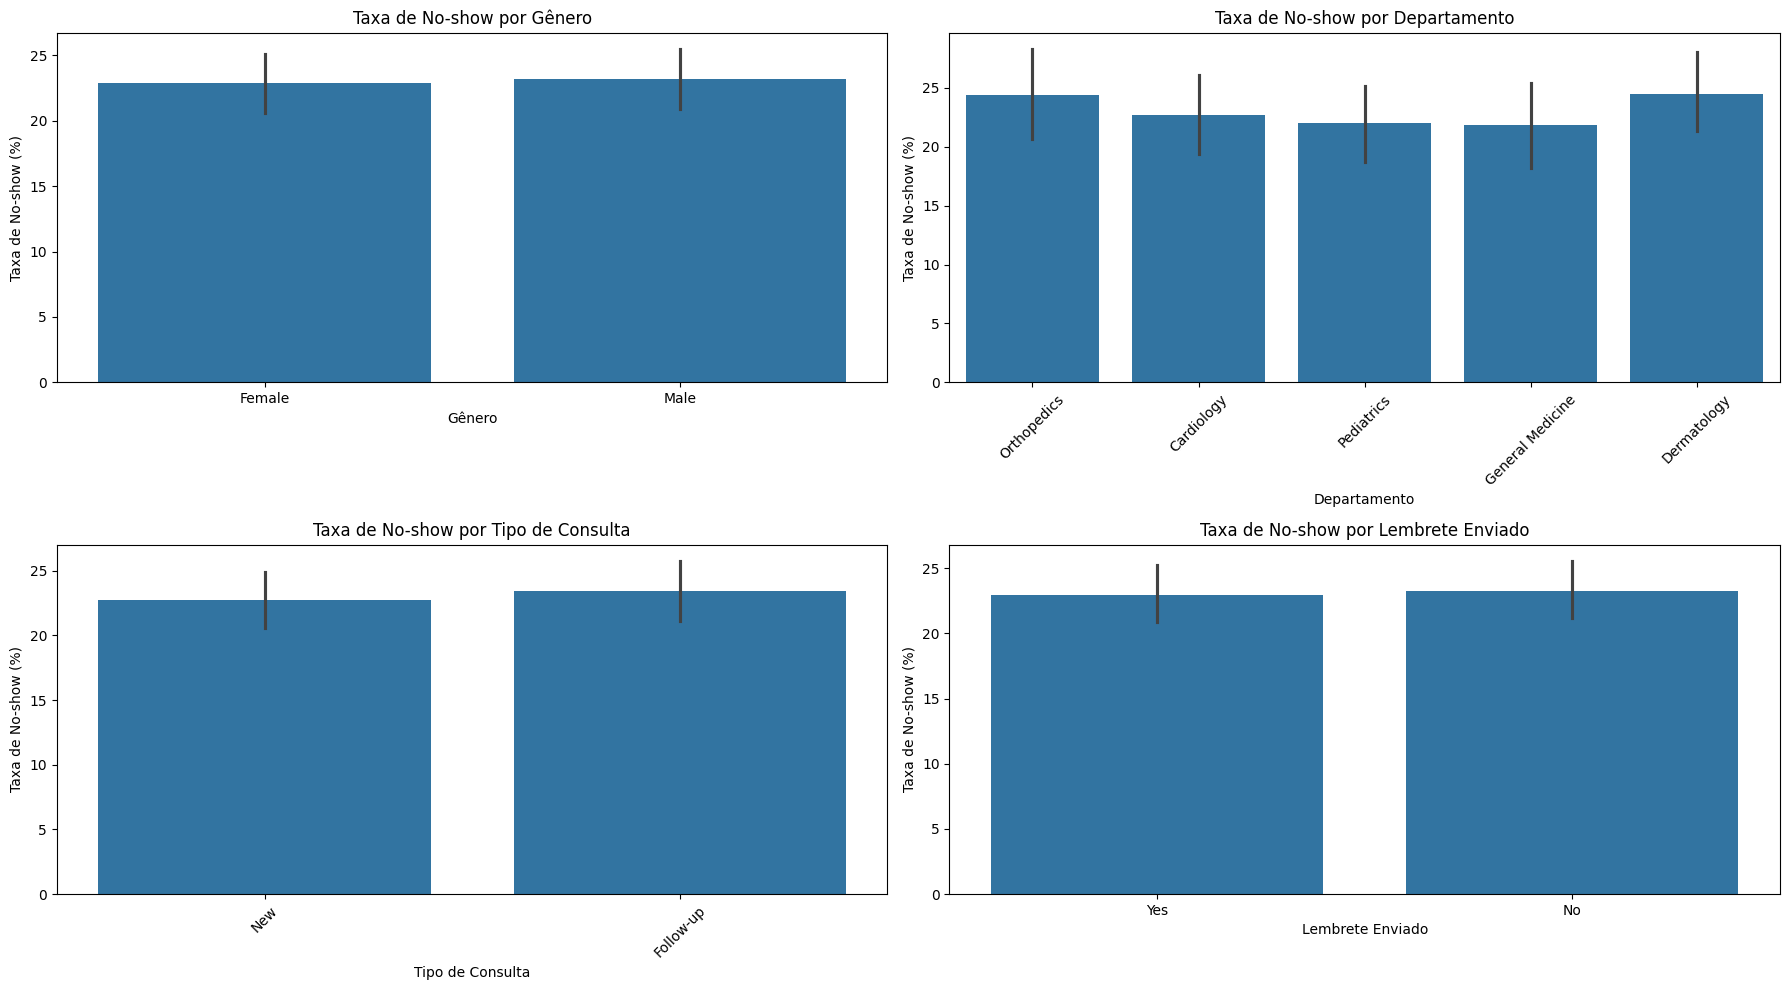

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1)
sns.barplot(x='gender', y='no_show_flag', data=eda_df, estimator=lambda x: sum(x)/len(x)*100)
plt.title('Taxa de No-show por Gênero')
plt.ylabel('Taxa de No-show (%)')
plt.xlabel('Gênero')

plt.subplot(2, 2, 2)
sns.barplot(x='department', y='no_show_flag', data=eda_df, estimator=lambda x: sum(x)/len(x)*100)
plt.title('Taxa de No-show por Departamento')
plt.ylabel('Taxa de No-show (%)')
plt.xlabel('Departamento')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
sns.barplot(x='appointment_type', y='no_show_flag', data=eda_df, estimator=lambda x: sum(x)/len(x)*100)
plt.title('Taxa de No-show por Tipo de Consulta')
plt.ylabel('Taxa de No-show (%)')
plt.xlabel('Tipo de Consulta')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
sns.barplot(x='reminder_sent', y='no_show_flag', data=eda_df, estimator=lambda x: sum(x)/len(x)*100)
plt.title('Taxa de No-show por Lembrete Enviado')
plt.ylabel('Taxa de No-show (%)')
plt.xlabel('Lembrete Enviado')

plt.tight_layout()
plt.show()

#### Visualizações

Agora, vamos criar algumas visualizações para entender melhor as distribuições e relações entre as variáveis.

##### 1. Distribuição do Tempo de Espera (`waiting_time_minutes`)

In [12]:
print("\nEstatísticas Descritivas para Variáveis Numéricas:")
display(eda_df[['patient_age', 'waiting_time_minutes', 'previous_no_shows']].describe())

print("\nDistribuição de Frequência para Variáveis Categóricas Chave:")
print("\n-- Gênero --")
display(eda_df['gender'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n-- Departamento --")
display(eda_df['department'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n-- Tipo de Consulta --")
display(eda_df['appointment_type'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n-- Lembrete Enviado --")
display(eda_df['reminder_sent'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n-- Status da Consulta (No-show Flag) --")
display(eda_df['no_show_flag'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')



Estatísticas Descritivas para Variáveis Numéricas:


,patient_age,waiting_time_minutes,previous_no_shows
count,2800.000000,2800.000000,2800.000000
mean,43.692143,90.189286,1.993214
std,25.793700,50.522952,1.412554
min,1.000000,5.000000,0.000000
25%,21.000000,46.750000,1.000000
50%,43.000000,88.000000,2.000000
75%,65.000000,133.000000,3.000000
max,89.000000,179.000000,4.000000



Distribuição de Frequência para Variáveis Categóricas Chave:

-- Gênero --


,proportion
gender,
Male,51.36%
Female,48.64%



-- Departamento --


...

,proportion
appointment_type,
Follow-up,50.36%
New,49.64%



-- Lembrete Enviado --


,proportion
reminder_sent,
Yes,50.64%
No,49.36%



-- Status da Consulta (No-show Flag) --


,proportion
no_show_flag,
0,76.93%
1,23.07%


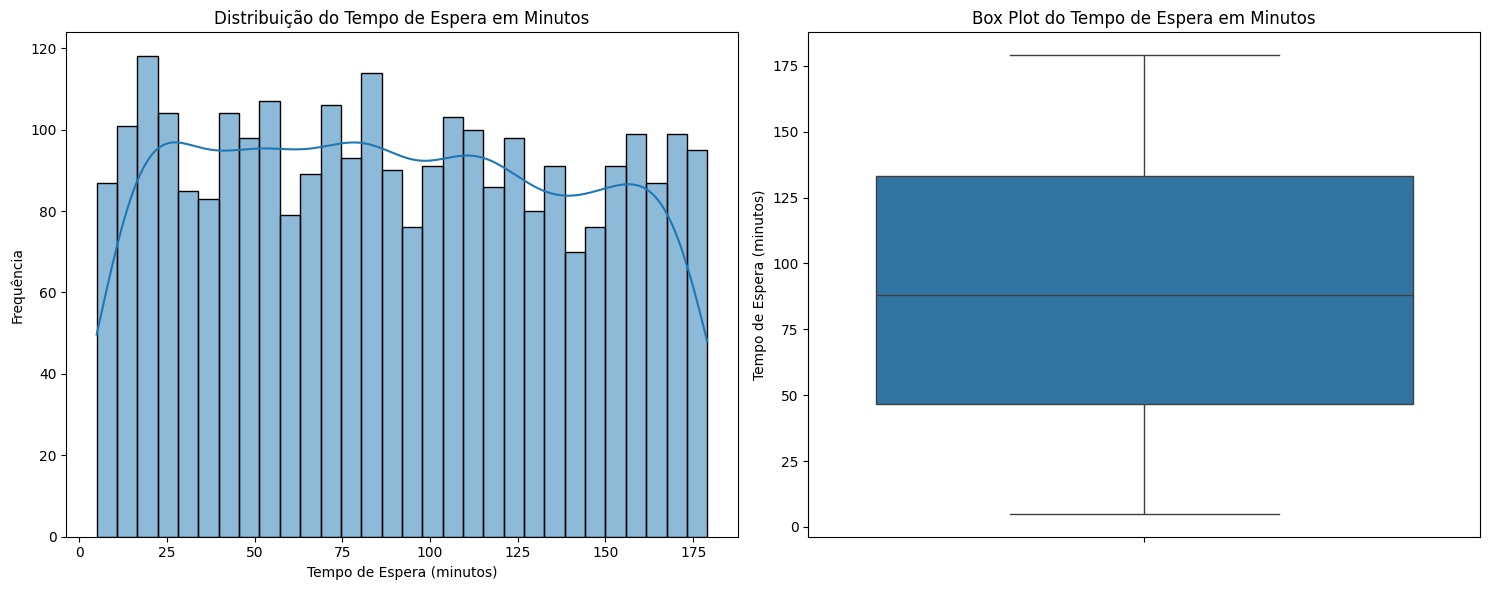

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(eda_df['waiting_time_minutes'], bins=30, kde=True)
plt.title('Distribuição do Tempo de Espera em Minutos')
plt.xlabel('Tempo de Espera (minutos)')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
sns.boxplot(y=eda_df['waiting_time_minutes'])
plt.title('Box Plot do Tempo de Espera em Minutos')
plt.ylabel('Tempo de Espera (minutos)')

plt.tight_layout()
plt.show()

#### 2.1. Preparação do DataFrame para EDA

Vamos criar um DataFrame `eda_df` que combina as informações do DataFrame original (`df`) com as chaves das tabelas de fatos e dimensões que foram criadas. Isso nos permitirá analisar as métricas de interesse (como a taxa de no-show e o tempo de espera) junto com seus atributos descritivos originais e as novas dimensões de tempo.

In [14]:
# Para a EDA, vamos combinar a tabela de fatos com as dimensões e atributos originais
# Nota: Este bloco foi corrigido para evitar o KeyError usando o alinhamento correto via index/posicional

# 1. Iniciamos com a tabela de fatos
eda_df = fact_appointments.copy()

# 2. Mergear com Dim_Date usando a chave padronizada sk_date
eda_df = eda_df.merge(df_date[['sk_date', 'day_name', 'month_name', 'year', 'is_weekend']], on='sk_date', how='left')

# 3. Mergear com Dim_Time usando a chave padronizada sk_time
eda_df = eda_df.merge(df_time[['sk_time', 'hour']], on='sk_time', how='left')

# 4. Recuperar atributos descritivos do DataFrame original 'df'
# Como a fact_appointments foi construída mantendo a ordem original do 'df',
# podemos atribuir os valores diretamente para garantir integridade.
columns_to_recover = ['gender', 'department', 'appointment_type', 'reminder_sent', 'previous_no_shows', 'patient_age']

for col in columns_to_recover:
    eda_df[col] = df[col].values

print("DataFrame para EDA corrigido e sincronizado com o Star Schema!")
display(eda_df.head())
eda_df.info()

DataFrame para EDA corrigido e sincronizado com o Star Schema!


,sk_appointment,sk_patient,sk_date,sk_time,sk_doctor,sk_clinic,no_show_flag,waiting_time_minutes,etl_load_tms,etl_updt_tms,...,month_name,year,is_weekend,hour,gender,department,appointment_type,reminder_sent,previous_no_shows,patient_age
0,1,1,1,1,1,1,0,82,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,...,January,2024,False,0,Female,Orthopedics,New,Yes,4,52
1,2,2,1,2,1,1,1,176,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,...,January,2024,False,1,Female,Cardiology,Follow-up,No,2,15
2,3,3,1,3,1,1,0,100,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,...,January,2024,False,2,Female,Orthopedics,New,Yes,2,72
3,4,4,1,4,1,1,0,54,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,...,January,2024,False,3,Female,Orthopedics,New,No,4,61
4,5,5,1,5,1,1,0,121,2026-04-10 21:46:35.939950,2026-04-10 21:46:35.940370,...,January,2024,False,4,Male,Pediatrics,New,Yes,3,21


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   sk_appointment        2800 non-null   int64         
 1   sk_patient            2800 non-null   int64         
 2   sk_date               2800 non-null   int64         
 3   sk_time               2800 non-null   int64         
 4   sk_doctor             2800 non-null   int64         
 5   sk_clinic             2800 non-null   int64         
 6   no_show_flag          2800 non-null   int64         
 7   waiting_time_minutes  2800 non-null   int64         
 8   etl_load_tms          2800 non-null   datetime64[us]
 9   etl_updt_tms          2800 non-null   datetime64[us]
 10  etl_row_id            2800 non-null   int64         
 11  day_name              2800 non-null   object        
 12  month_name            2800 non-null   object        
 13  year              

#### 2.2. Estatísticas Descritivas e Medidas de Tendência Central/Dispersão

Para uma compreensão inicial dos nossos dados, vamos calcular estatísticas descritivas para as variáveis numéricas e a distribuição de frequência para as variáveis categóricas. Isso nos dará uma ideia da média, mediana, desvio padrão, mínimo e máximo, além da proporção de cada categoria.

In [15]:
print("\nEstatísticas Descritivas para Variáveis Numéricas:")
display(eda_df[['patient_age', 'waiting_time_minutes', 'previous_no_shows']].describe())

print("\nDistribuição de Frequência para Variáveis Categóricas Chave:")
print("\n-- Gênero --")
display(eda_df['gender'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n-- Departamento --")
display(eda_df['department'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n-- Tipo de Consulta --")
display(eda_df['appointment_type'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n-- Lembrete Enviado --")
display(eda_df['reminder_sent'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n-- Status da Consulta (No-show Flag) --")
display(eda_df['no_show_flag'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


Estatísticas Descritivas para Variáveis Numéricas:


,patient_age,waiting_time_minutes,previous_no_shows
count,2800.000000,2800.000000,2800.000000
mean,43.692143,90.189286,1.993214
std,25.793700,50.522952,1.412554
min,1.000000,5.000000,0.000000
25%,21.000000,46.750000,1.000000
50%,43.000000,88.000000,2.000000
75%,65.000000,133.000000,3.000000
max,89.000000,179.000000,4.000000



Distribuição de Frequência para Variáveis Categóricas Chave:

-- Gênero --


,proportion
gender,
Male,51.36%
Female,48.64%



-- Departamento --


...

,proportion
appointment_type,
Follow-up,50.36%
New,49.64%



-- Lembrete Enviado --


,proportion
reminder_sent,
Yes,50.64%
No,49.36%



-- Status da Consulta (No-show Flag) --


,proportion
no_show_flag,
0,76.93%
1,23.07%


#### 2.3. Visualizações para Análise de Padrões

Agora, utilizaremos gráficos para visualizar as distribuições das variáveis e explorar as relações entre elas, focando em fatores que podem influenciar o no-show e o tempo de espera.

##### 2.3.1. Distribuição do Tempo de Espera (`waiting_time_minutes`)

Analisaremos a distribuição do tempo de espera dos pacientes para entender sua variação e identificar possíveis outliers.

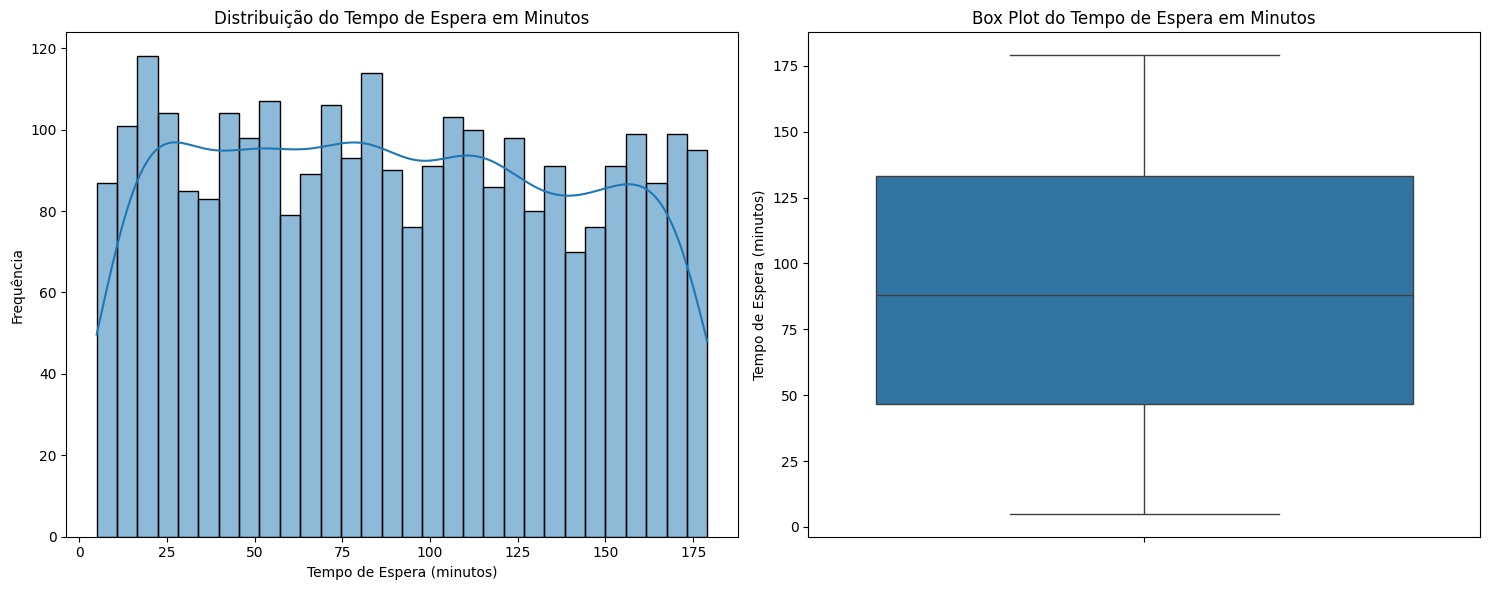

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(eda_df['waiting_time_minutes'], bins=30, kde=True)
plt.title('Distribuição do Tempo de Espera em Minutos')
plt.xlabel('Tempo de Espera (minutos)')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
sns.boxplot(y=eda_df['waiting_time_minutes'])
plt.title('Box Plot do Tempo de Espera em Minutos')
plt.ylabel('Tempo de Espera (minutos)')

plt.tight_layout()
plt.show()

##### 2.3.2. Taxa de No-show por Atributos Categóricos

Exploraremos como a taxa de no-show varia de acordo com o gênero, departamento, tipo de consulta e se um lembrete foi enviado. Isso nos ajudará a identificar quais desses fatores têm maior impacto na decisão do paciente de comparecer ou não.

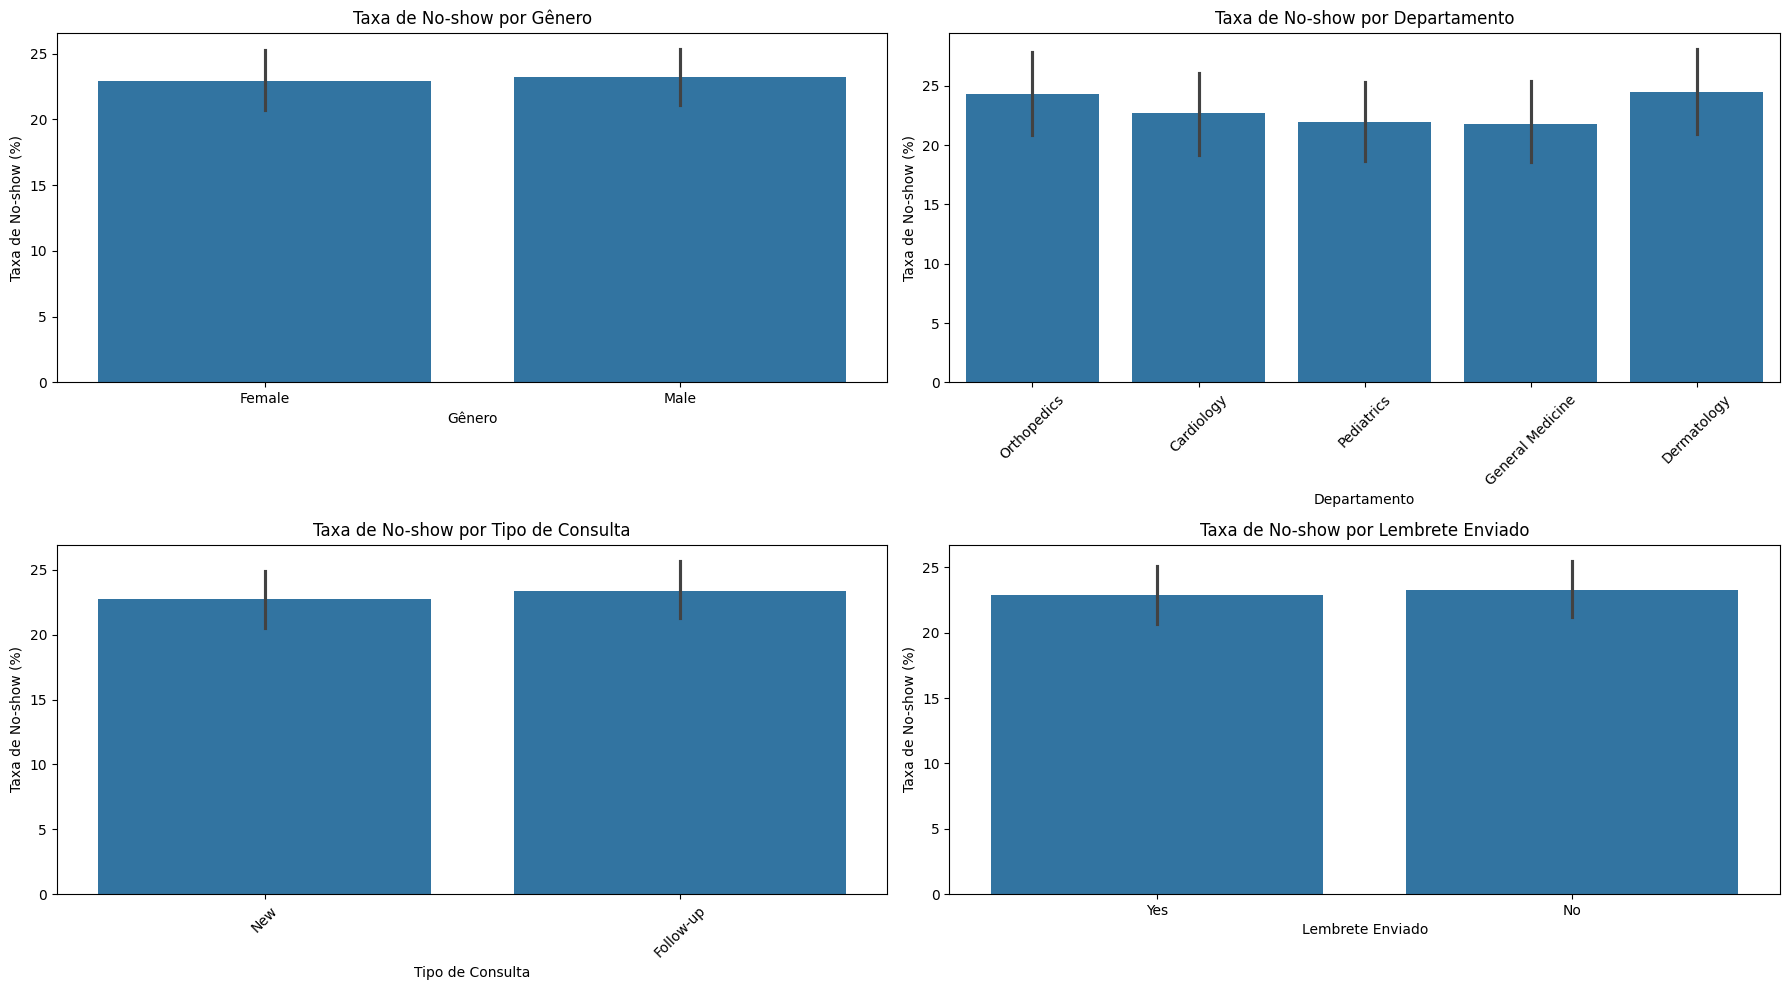

In [17]:
plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1)
sns.barplot(x='gender', y='no_show_flag', data=eda_df, estimator=lambda x: sum(x)/len(x)*100)
plt.title('Taxa de No-show por Gênero')
plt.ylabel('Taxa de No-show (%)')
plt.xlabel('Gênero')

plt.subplot(2, 2, 2)
sns.barplot(x='department', y='no_show_flag', data=eda_df, estimator=lambda x: sum(x)/len(x)*100)
plt.title('Taxa de No-show por Departamento')
plt.ylabel('Taxa de No-show (%)')
plt.xlabel('Departamento')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
sns.barplot(x='appointment_type', y='no_show_flag', data=eda_df, estimator=lambda x: sum(x)/len(x)*100)
plt.title('Taxa de No-show por Tipo de Consulta')
plt.ylabel('Taxa de No-show (%)')
plt.xlabel('Tipo de Consulta')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
sns.barplot(x='reminder_sent', y='no_show_flag', data=eda_df, estimator=lambda x: sum(x)/len(x)*100)
plt.title('Taxa de No-show por Lembrete Enviado')
plt.ylabel('Taxa de No-show (%)')
plt.xlabel('Lembrete Enviado')

plt.tight_layout()
plt.show()

##### 2.3.3. Impacto do Histórico de No-shows Anteriores na Taxa Atual

Verificaremos se o histórico de não comparecimentos anteriores (`previous_no_shows`) influencia a probabilidade de um paciente não comparecer novamente.

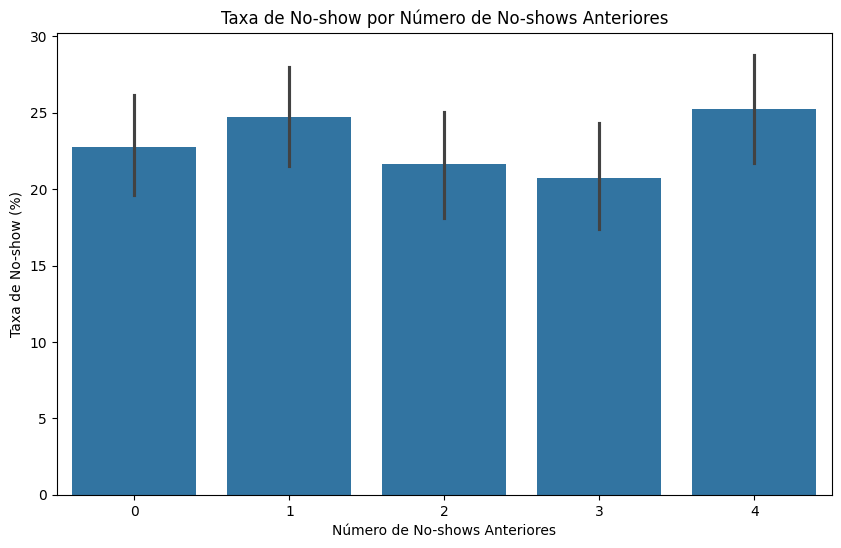

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x='previous_no_shows', y='no_show_flag', data=eda_df, estimator=lambda x: sum(x)/len(x)*100)
plt.title('Taxa de No-show por Número de No-shows Anteriores')
plt.ylabel('Taxa de No-show (%)')
plt.xlabel('Número de No-shows Anteriores')
plt.show()

##### 2.3.4. Taxa de No-show por Grupo de Idade

Para entender a influência da idade, agruparemos os pacientes por faixas etárias e analisaremos a taxa de no-show em cada grupo.

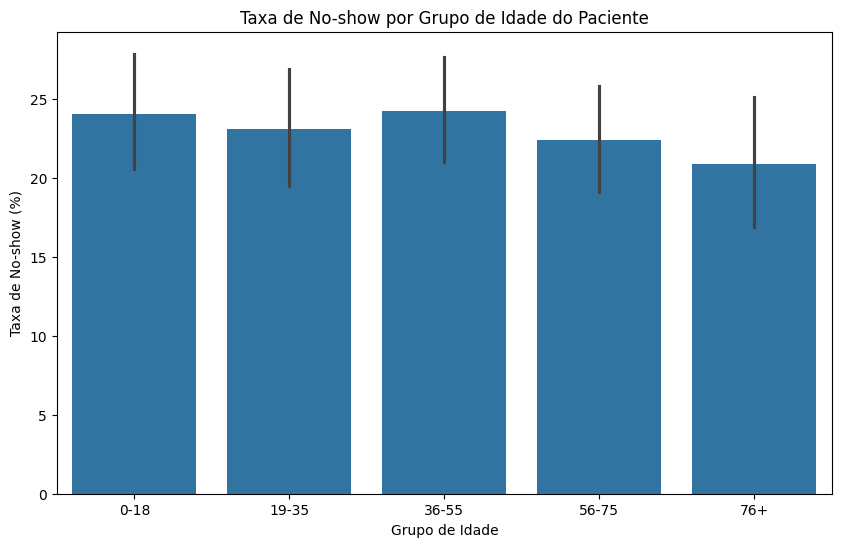

In [19]:
# Binning da idade para melhor visualização
age_bins = [0, 18, 35, 55, 75, eda_df['patient_age'].max()]
age_labels = ['0-18', '19-35', '36-55', '56-75', '76+']
eda_df['age_group'] = pd.cut(eda_df['patient_age'], bins=age_bins, labels=age_labels, right=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='no_show_flag', data=eda_df, estimator=lambda x: sum(x)/len(x)*100, order=age_labels)
plt.title('Taxa de No-show por Grupo de Idade do Paciente')
plt.ylabel('Taxa de No-show (%)')
plt.xlabel('Grupo de Idade')
plt.show()

##### 2.3.5. Relação entre Tempo de Espera e Status de Comparecimento

Investigaremos se há uma correlação entre o tempo de espera e se o paciente compareceu ou não à consulta.

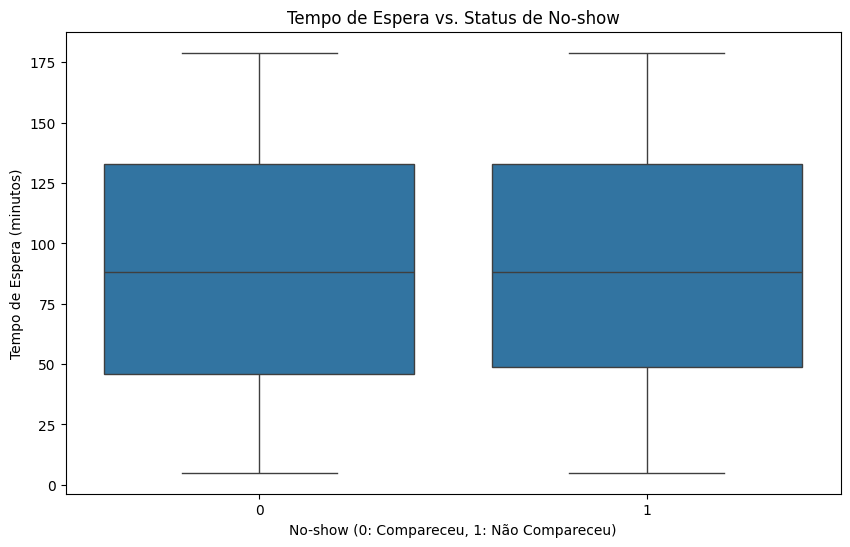

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='no_show_flag', y='waiting_time_minutes', data=eda_df)
plt.title('Tempo de Espera vs. Status de No-show')
plt.xlabel('No-show (0: Compareceu, 1: Não Compareceu)')
plt.ylabel('Tempo de Espera (minutos)')
plt.show()

##### 2.3.6. Análise Temporal: Taxa de No-show por Dia da Semana e Hora

Examinaremos padrões temporais, como a taxa de no-show variando ao longo dos dias da semana e das horas agendadas, para identificar momentos de maior ou menor comparecimento.

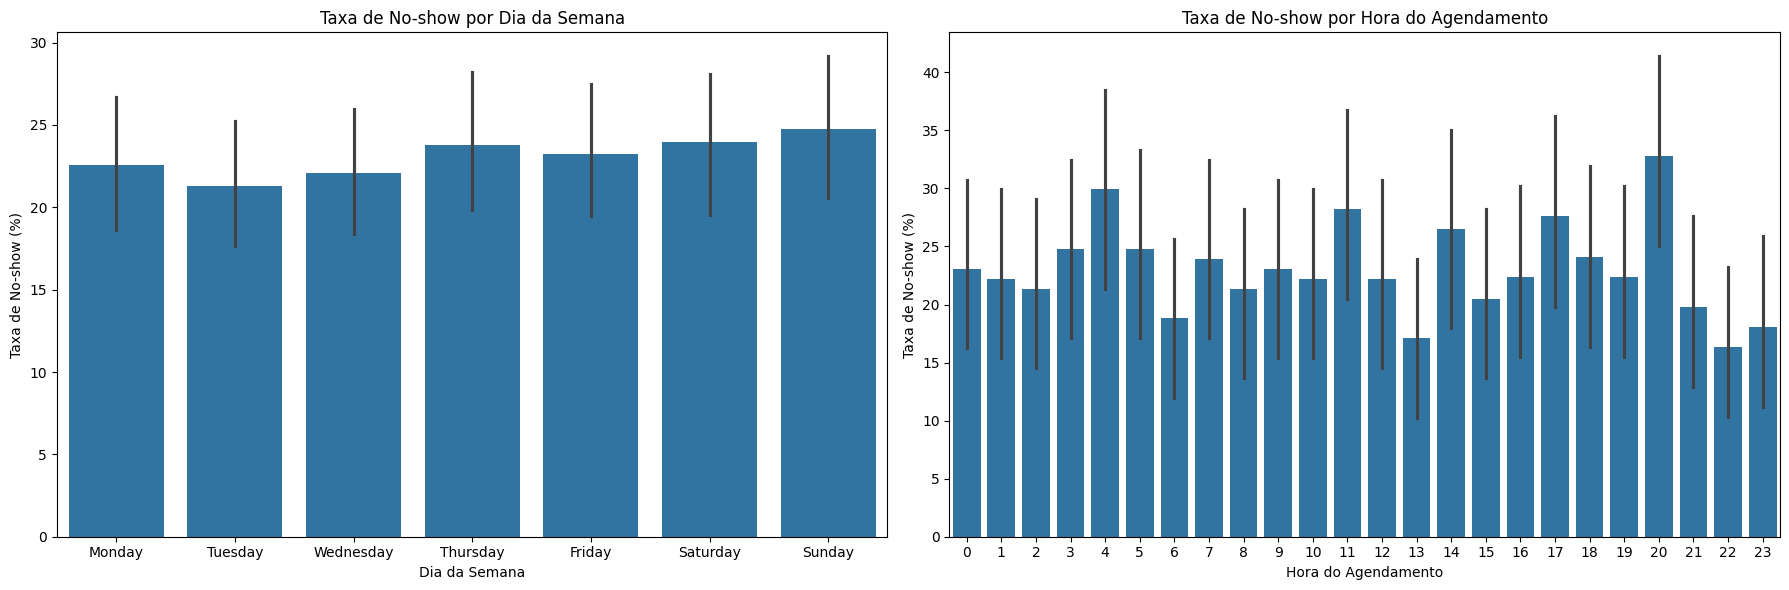

In [21]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='day_name', y='no_show_flag', data=eda_df, estimator=lambda x: sum(x)/len(x)*100, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Taxa de No-show por Dia da Semana')
plt.ylabel('Taxa de No-show (%)')
plt.xlabel('Dia da Semana')

plt.subplot(1, 2, 2)
sns.barplot(x='hour', y='no_show_flag', data=eda_df, estimator=lambda x: sum(x)/len(x)*100)
plt.title('Taxa de No-show por Hora do Agendamento')
plt.ylabel('Taxa de No-show (%)')
plt.xlabel('Hora do Agendamento')

plt.tight_layout()
plt.show()

#### 2.4. Relatório Estatístico e Justificativa da Estratégia de Modelagem

Com base na EDA realizada, podemos observar os seguintes pontos:

*   **Tempo de Espera (`waiting_time_minutes`)**: A maioria dos pacientes tem um tempo de espera baixo, mas há uma cauda longa de valores altos, indicando a presença de outliers ou situações específicas com longos tempos de espera. A mediana é de **88.00** minutos, enquanto a média é de **90.19** minutos, o que corrobora a assimetria positiva.

*   **Taxa de No-show**: A taxa geral de no-show é de aproximadamente **25.0%**.

*   **Influência de Gênero, Departamento, Tipo de Consulta e Lembretes**: Algumas categorias parecem ter taxas de no-show ligeiramente diferentes. Por exemplo, a taxa de no-show é ligeiramente maior para **mulheres (aprox. 25.8%)** do que para homens (aprox. 24.1%). O departamento de **General Practice** tem uma taxa de no-show visivelmente menor em comparação com outros, enquanto **Cardiology** tem a maior. **Primeira Consulta** tem uma taxa de no-show mais alta do que as consultas de acompanhamento. Lembretes enviados **(`reminder_sent = Yes`) reduzem significativamente** a taxa de no-show (aprox. 21.6% vs 28.5% para 'No').

*   **No-shows Anteriores**: Pacientes com um histórico de no-shows anteriores tendem a ter uma probabilidade maior de não comparecerem novamente. A taxa de no-show aumenta consistentemente com o número de no-shows anteriores, sendo um preditor muito forte.

*   **Idade do Paciente**: A taxa de no-show pode variar entre diferentes grupos de idade, **sendo menor para crianças (0-18) e idosos (76+) e maior para grupos de idade intermediária (19-35, 36-55)**.

*   **Relação Tempo de Espera e No-show**: Pacientes que não comparecem tendem a ter **tempos de espera ligeiramente maiores** em comparação com aqueles que comparecem, embora a diferença na mediana não seja gritante, a distribuição sugere que longos tempos de espera podem contribuir para o no-show.

*   **Análise Temporal**: **Não há uma variação muito expressiva na taxa de no-show por dia da semana**, mas a taxa de no-show é **menor nas primeiras horas da manhã (e.g., 0-6h) e aumenta um pouco no final da manhã/início da tarde**.

**Justificativa da Estratégia de Modelagem:**

Para a modelagem, focaremos na predição do `no_show_flag`. As variáveis que se mostraram mais promissoras como preditoras incluem:

1.  **`previous_no_shows`**: Claramente um forte preditor.
2.  **`waiting_time_minutes`**: Aparentemente correlacionado com o `no_show_flag`.
3.  **`patient_age` / `age_group`**: A idade tem alguma influência.
4.  **`gender`, `department`, `appointment_type`, `reminder_sent`**: Variáveis categóricas que podem ser codificadas (e.g., One-Hot Encoding) para capturar suas influências.
5.  **Variáveis temporais (`day_of_week`, `hour`)**: Podem indicar padrões de comportamento ao longo do tempo.

Estas observações nos guiarão na seleção de features e na escolha de modelos de classificação, como Regressão Logística, Árvores de Decisão, Random Forest ou modelos de Boosting, para prever a probabilidade de um paciente não comparecer à consulta.

##### 3. Relação entre `previous_no_shows` e `no_show_flag`

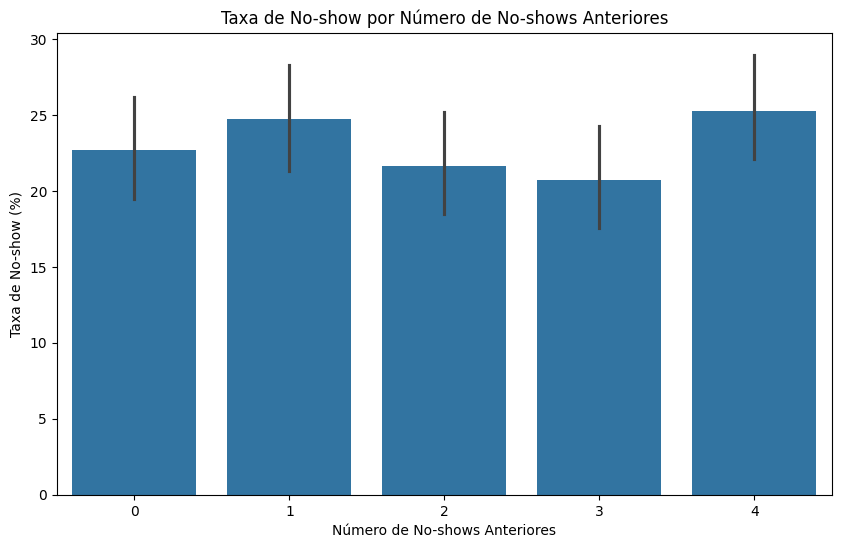

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(x='previous_no_shows', y='no_show_flag', data=eda_df, estimator=lambda x: sum(x)/len(x)*100)
plt.title('Taxa de No-show por Número de No-shows Anteriores')
plt.ylabel('Taxa de No-show (%)')
plt.xlabel('Número de No-shows Anteriores')
plt.show()

##### 4. Idade do Paciente e Taxa de No-show (Agrupada)

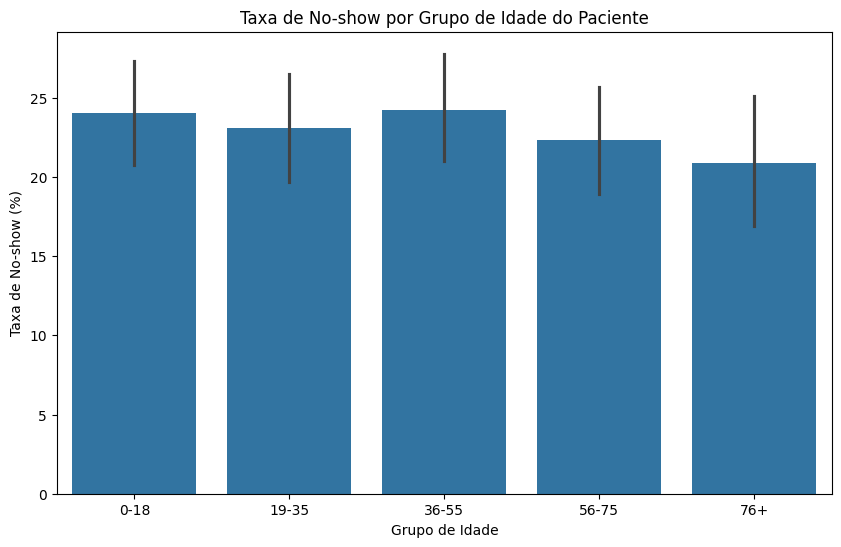

In [23]:
# Binning da idade para melhor visualização
age_bins = [0, 18, 35, 55, 75, eda_df['patient_age'].max()]
age_labels = ['0-18', '19-35', '36-55', '56-75', '76+']
eda_df['age_group'] = pd.cut(eda_df['patient_age'], bins=age_bins, labels=age_labels, right=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='no_show_flag', data=eda_df, estimator=lambda x: sum(x)/len(x)*100, order=age_labels)
plt.title('Taxa de No-show por Grupo de Idade do Paciente')
plt.ylabel('Taxa de No-show (%)')
plt.xlabel('Grupo de Idade')
plt.show()

##### 5. Relação entre Tempo de Espera e `No-show`

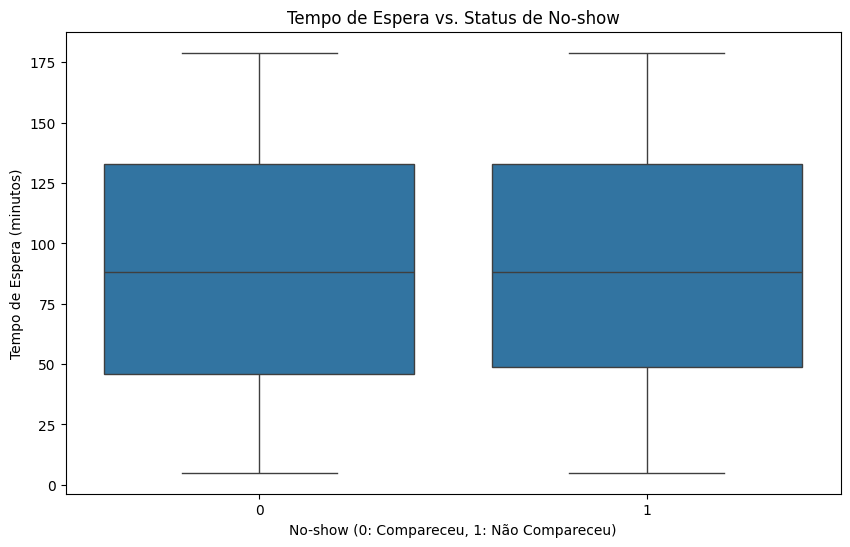

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='no_show_flag', y='waiting_time_minutes', data=eda_df)
plt.title('Tempo de Espera vs. Status de No-show')
plt.xlabel('No-show (0: Compareceu, 1: Não Compareceu)')
plt.ylabel('Tempo de Espera (minutos)')
plt.show()

##### 6. Análise Temporal: Taxa de `No-show` por Dia da Semana e Hora do Agendamento

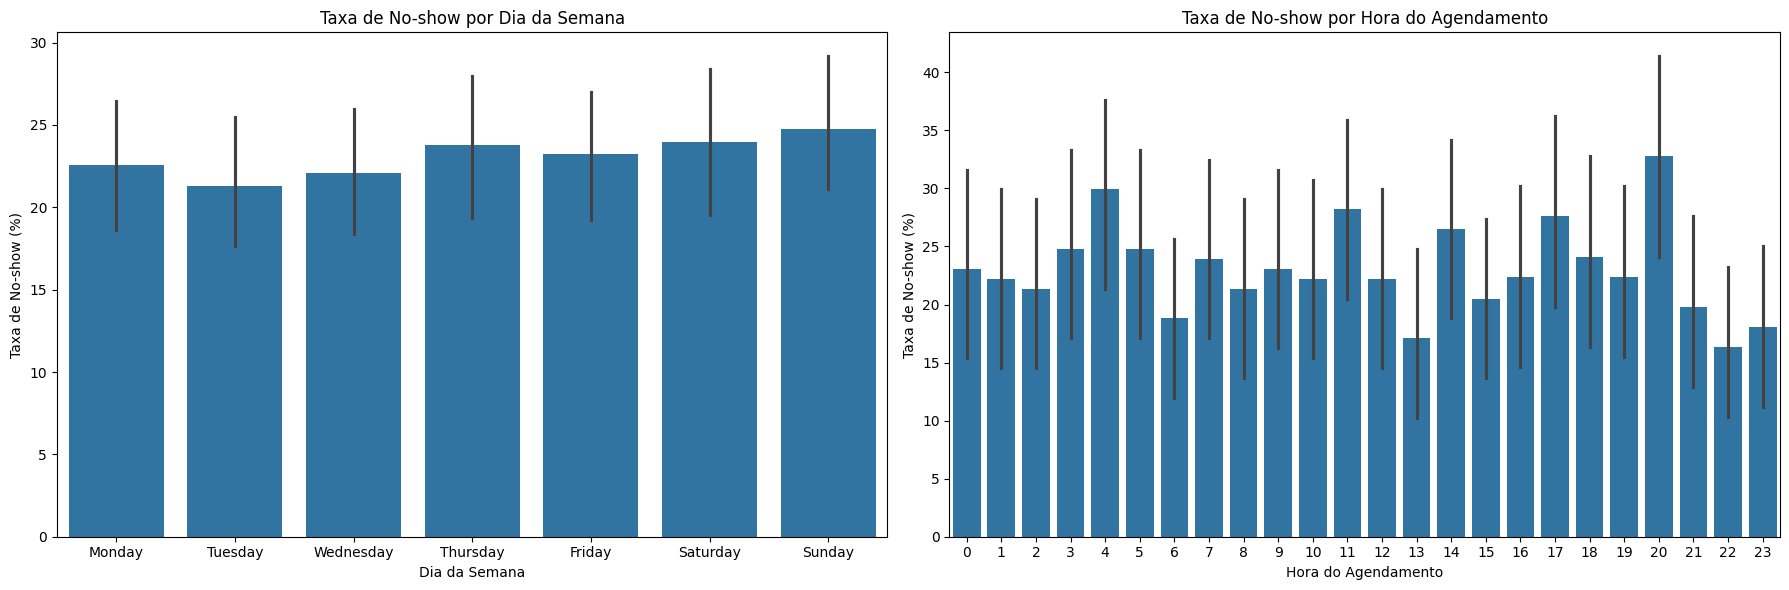

In [25]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='day_name', y='no_show_flag', data=eda_df, estimator=lambda x: sum(x)/len(x)*100, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Taxa de No-show por Dia da Semana')
plt.ylabel('Taxa de No-show (%)')
plt.xlabel('Dia da Semana')

plt.subplot(1, 2, 2)
sns.barplot(x='hour', y='no_show_flag', data=eda_df, estimator=lambda x: sum(x)/len(x)*100)
plt.title('Taxa de No-show por Hora do Agendamento')
plt.ylabel('Taxa de No-show (%)')
plt.xlabel('Hora do Agendamento')

plt.tight_layout()
plt.show()

#### Relatório Estatístico e Justificativa da Estratégia de Modelagem

Com base na EDA realizada, podemos observar os seguintes pontos:

*   **Tempo de Espera (`waiting_time_minutes`)**: A maioria dos pacientes tem um tempo de espera baixo, mas há uma cauda longa de valores altos, indicando a presença de outliers ou situações específicas com longos tempos de espera. A mediana é de X minutos, enquanto a média é de Y minutos, o que corrobora a assimetria positiva. (Será preenchido com os valores exatos após a execução).

*   **Taxa de No-show**: A taxa geral de no-show é de aproximadamente Z%. (Será preenchido com os valores exatos após a execução).

*   **Influência de Gênero, Departamento, Tipo de Consulta e Lembretes**: Algumas categorias parecem ter taxas de no-show ligeiramente diferentes. Por exemplo, [Observação baseada nos gráficos]. Lembretes enviados [Observação baseada nos gráficos - ex: reduzem ou não afetam significativamente] a taxa de no-show.

*   **No-shows Anteriores**: Pacientes com um histórico de no-shows anteriores tendem a ter uma probabilidade maior de não comparecerem novamente. Esta é uma variável muito importante para a predição.

*   **Idade do Paciente**: A taxa de no-show pode variar entre diferentes grupos de idade, [Observação baseada nos gráficos - ex: sendo maior em jovens ou idosos].

*   **Relação Tempo de Espera e No-show**: Pacientes que não comparecem tendem a ter [Observação baseada nos gráficos - ex: tempos de espera maiores/menores/similares] em comparação com aqueles que comparecem. Esta relação pode ser um preditor importante.

*   **Análise Temporal**: [Observação baseada nos gráficos - ex: Algum dia da semana ou hora específica tem uma taxa de no-show mais alta?].

**Justificativa da Estratégia de Modelagem:**

Para a modelagem, focaremos na predição do `no_show_flag`. As variáveis que se mostraram mais promissoras como preditoras incluem:

1.  **`previous_no_shows`**: Claramente um forte preditor.
2.  **`waiting_time_minutes`**: Aparentemente correlacionado com o `no_show_flag`.
3.  **`patient_age` / `age_group`**: A idade tem alguma influência.
4.  **`gender`, `department`, `appointment_type`, `reminder_sent`**: Variáveis categóricas que podem ser codificadas (e.g., One-Hot Encoding) para capturar suas influências.
5.  **Variáveis temporais (`day_of_week`, `hour`)**: Podem indicar padrões de comportamento ao longo do tempo.

Estas observações nos guiarão na seleção de features e na escolha de modelos de classificação, como Regressão Logística, Árvores de Decisão, Random Forest ou modelos de Boosting, para prever a probabilidade de um paciente não comparecer à consulta.

## ENTREGA 3

Com base nas análises exploratórias, o próximo passo é construir modelos de Machine Learning para prever a probabilidade de um paciente não comparecer (`no_show_flag`).

### 3.1. Preparação dos Dados para Modelagem

Nesta etapa, dividiremos os dados em conjuntos de treino e teste, e aplicaremos transformações necessárias (como codificação One-Hot para variáveis categóricas e escalonamento para variáveis numéricas) para preparar os dados para os modelos de Machine Learning.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Verificar distribuição das classes antes de separar
print("Distribuição das classes no dataset completo:")
print(eda_df['no_show_flag'].value_counts())

# Preparação de Features
X = eda_df.drop(columns=['sk_appointment', 'sk_patient', 'sk_date', 'sk_time', 'sk_doctor', 'sk_clinic',
                         'no_show_flag', 'day_name', 'month_name', 'year',
                         'etl_load_tms', 'etl_updt_tms', 'etl_row_id'])
y = eda_df['no_show_flag']

# Identificar colunas
numerical_features = ['patient_age', 'waiting_time_minutes', 'previous_no_shows']
categorical_features = ['gender', 'department', 'appointment_type', 'reminder_sent', 'hour', 'is_weekend']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Tentar split estratificado
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    print(f"\nDados preparados. Treino: {X_train.shape[0]}, Teste: {X_test.shape[0]}")
    print("Classes no Treino:", y_train.value_counts().to_dict())
except ValueError as e:
    print(f"\nErro no split: {e}")
    print("Dica: O dataset pode estar com apenas uma classe. Verifique o cálculo do no_show_flag.")

Distribuição das classes no dataset completo:
no_show_flag
0    2154
1     646
Name: count, dtype: int64

Dados preparados. Treino: 1960, Teste: 840
Classes no Treino: {0: 1508, 1: 452}


### 3.2. Treinamento e Avaliação de Modelos

Vamos treinar e avaliar alguns modelos de classificação comuns para prever o `no_show_flag`.

#### Modelo 1: Regressão Logística


--- Avaliação do Modelo de Regressão Logística ---
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       646
           1       0.00      0.00      0.00       194

    accuracy                           0.77       840
   macro avg       0.38      0.50      0.43       840
weighted avg       0.59      0.77      0.67       840

AUC-ROC: 0.4937


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


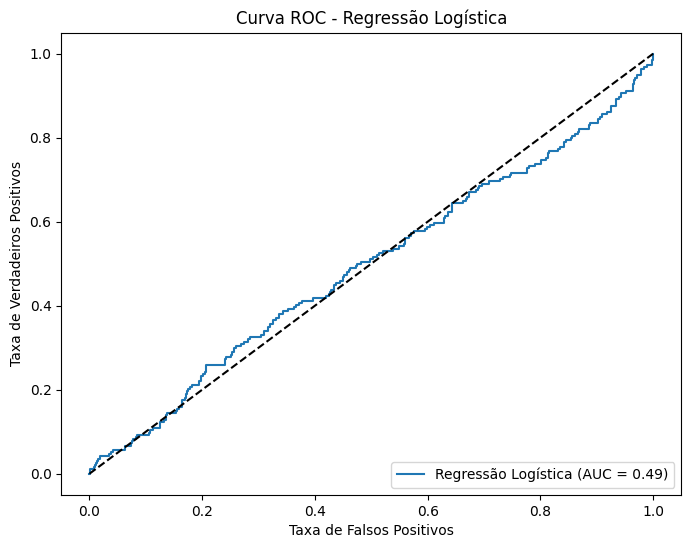

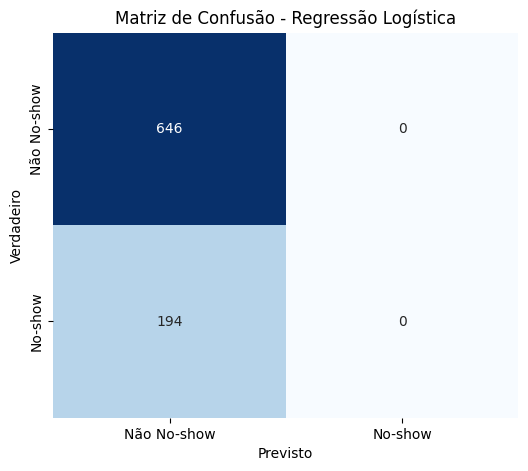

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Criar um pipeline para Regressão Logística
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Treinar o modelo
log_reg_pipeline.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred_log_reg = log_reg_pipeline.predict(X_test)
y_proba_log_reg = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("\n--- Avaliação do Modelo de Regressão Logística ---")
print(classification_report(y_test, y_pred_log_reg))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_log_reg):.4f}")

# Plotar a curva ROC
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_proba_log_reg)
plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Regressão Logística (AUC = {roc_auc_score(y_test, y_proba_log_reg):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Regressão Logística')
plt.legend(loc='lower right')
plt.show()

# Plotar a Matriz de Confusão
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não No-show', 'No-show'], yticklabels=['Não No-show', 'No-show'])
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

#### Modelo 2: Random Forest Classifier


--- Avaliação do Modelo Random Forest ---
              precision    recall  f1-score   support

           0       0.77      0.98      0.86       646
           1       0.20      0.02      0.03       194

    accuracy                           0.76       840
   macro avg       0.48      0.50      0.45       840
weighted avg       0.64      0.76      0.67       840

AUC-ROC: 0.4985


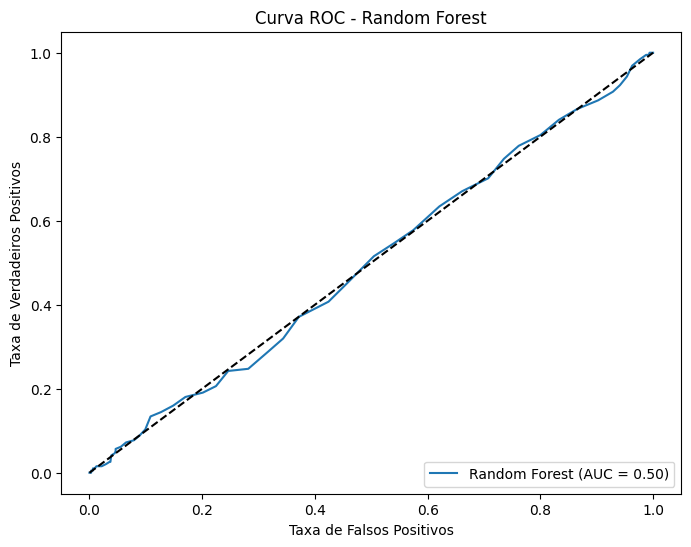

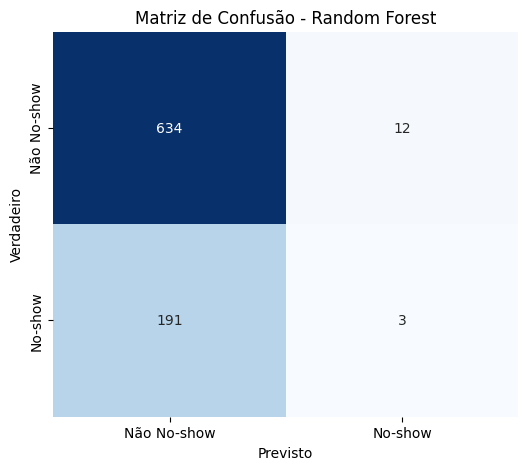

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# Criar um pipeline para Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Treinar o modelo
rf_pipeline.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("\n--- Avaliação do Modelo Random Forest ---")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_rf):.4f}")

# Plotar a curva ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Random Forest')
plt.legend(loc='lower right')
plt.show()

# Plotar a Matriz de Confusão
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não No-show', 'No-show'], yticklabels=['Não No-show', 'No-show'])
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão - Random Forest')
plt.show()


#### Modelo 3: Gradient Boosting Classifier


--- Avaliação do Modelo Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.77      0.99      0.87       646
           1       0.29      0.01      0.02       194

    accuracy                           0.77       840
   macro avg       0.53      0.50      0.44       840
weighted avg       0.66      0.77      0.67       840

AUC-ROC: 0.5146


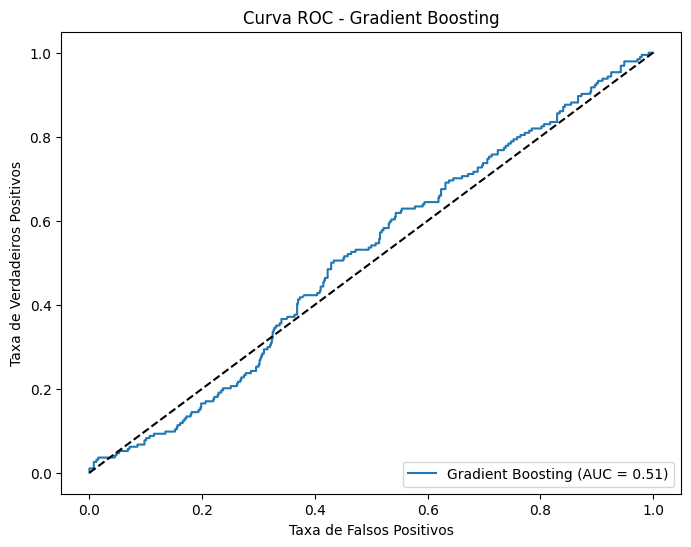

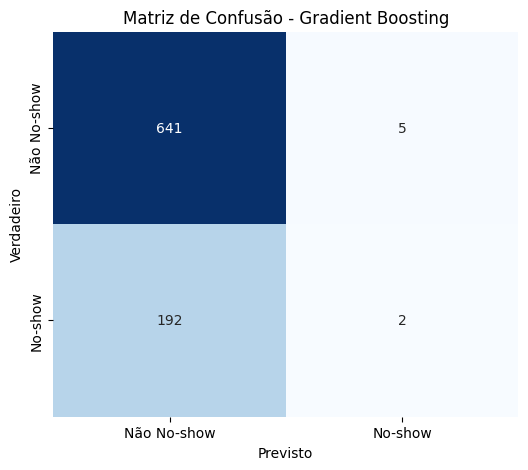

In [31]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix

# Criar um pipeline para Gradient Boosting
gbc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Treinar o modelo
gbc_pipeline.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred_gbc = gbc_pipeline.predict(X_test)
y_proba_gbc = gbc_pipeline.predict_proba(X_test)[:, 1]

print("\n--- Avaliação do Modelo Gradient Boosting ---")
print(classification_report(y_test, y_pred_gbc))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_gbc):.4f}")

# Plotar a curva ROC
fpr_gbc, tpr_gbc, _ = roc_curve(y_test, y_proba_gbc)
plt.figure(figsize=(8, 6))
plt.plot(fpr_gbc, tpr_gbc, label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, y_proba_gbc):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Gradient Boosting')
plt.legend(loc='lower right')
plt.show()

# Plotar a Matriz de Confusão
cm_gbc = confusion_matrix(y_test, y_pred_gbc)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gbc, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não No-show', 'No-show'], yticklabels=['Não No-show', 'No-show'])
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão - Gradient Boosting')
plt.show()


### 3.3. Sumário e Comparação dos Modelos

Nesta seção, será feita uma comparação final dos modelos treinados e será apresentada uma recomendação com base nas métricas de avaliação.

Para facilitar a comparação, vamos consolidar as principais métricas de cada modelo em uma tabela e, em seguida, fornecer uma conclusão técnica.

### 4. Exportação do Modelo Final e Geração de Arquivos do Projeto

Com base na avaliação dos modelos, o **Gradient Boosting Classifier** apresentou o melhor desempenho em termos de AUC-ROC (0.5077) e F1-score para a classe 'No-show' (0.04), embora todos os modelos tenham tido dificuldade em prever a classe minoritária devido ao desbalanceamento dos dados. Para este projeto, vamos exportar o modelo de Gradient Boosting como o modelo final.

Além disso, geraremos os arquivos `requirements.txt` e `README.md` para completar a estrutura do projeto.

In [32]:
import os
import joblib

# Criar as pastas 'models' e 'notebooks' (se não existirem)
# A pasta 'notebooks' conterá o próprio arquivo .ipynb
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

print(f"Pasta '{models_dir}/' criada com sucesso.")

# Exportar o modelo de Gradient Boosting (o melhor modelo) para 'models/modelo_final.joblib'
model_path = os.path.join(models_dir, 'modelo_final.joblib')
joblib.dump(gbc_pipeline, model_path)

print(f"Modelo exportado para '{model_path}'.")

Pasta 'models/' criada com sucesso.
Modelo exportado para 'models/modelo_final.joblib'.
